*Code by Shagun Kala* https://medium.com/@kala.shagun/stock-market-prediction-using-news-sentiments-f9101e5ee1f4. This has been heavily edited, especially, we have moved to a Torch model. 

## Exercise 5 b, stock price prediction with Twitter sentiment data and Neural Networks

In this exercise, we try to estimate index price movements using Nifty50 index data, Twitter sentiment analysis and a few deep learning models, first, a simpler, older model, then a contemporary transformer-based model. We have nearly 65 000 tweets from 01/01/2015 to 31/12/2019 and daily Nifty index prices   

Finance is highly non-linear and non-stationary. Traditional time-series methods (ARIMA, SARIMAX) are only effective for stationary data. However, when modifying financial data stationarity (log-return etc) we typically lose information. Neural networks don't require any stationarity. 


part 1: Twitter sentiment analysis

part 2: DL with Nifty50 index data and Twitter sentiments. 

In this exercise, all you need to do is some fairly traditional coding. The focus is on understanding the process. 


In [2]:
pip install --upgrade vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install vaderSentiment
!pip install tensorflow
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
    --------------------------------------- 5.8/376.0 MB 27.1 MB/s eta 0:00:14
   - -------------------------------------- 11.3/376.0 MB 26.1 MB/s eta 0:00:14
   - -------------------------------------- 16.5/376.0 MB 26.0 MB/s eta 0:00:14
   -- ------------------------------------- 22.0/376.0 MB 25.8 MB/s eta 0:00:14
   -- ------------------------------------- 27.3/376.0 MB 25.8 MB/s eta 0:00:14
   --- ------------------------------------ 32.5/376.0 MB 25.8 MB/s eta 0:00:14
   --- ------------------------------------ 35.1/376.0 MB 24.0 MB/s eta 0:00:15
   ---- ----------------------------------- 39.8/376.0 MB 23.7 MB/s eta 0:00:15
   ---- ----------------------------------- 45.4/376.0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
# pip install scikit-learn

In [4]:
import pandas as pd
from urllib.request import Request, urlopen
from bs4 import BeautifulSoup as soup
import random
import re
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import date
import numpy as np
from sklearn.preprocessing import MinMaxScaler
#from sklearn.metrics import mean_squared_error
#from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

## Part 1: Twitter sentiment analysis

#### 1. We download the Twitter data 

In [29]:
ndtv1 = pd.read_csv('niftydata/NDTVProfit_2015-1-1_2016-5-1.csv')
ndtv2 = pd.read_csv('niftydata/NDTVProfit_2016-5-1_2016-8-1.csv')
ndtv3 = pd.read_csv('niftydata/NDTVProfit_2016-8-1_2017-1-1.csv')
ndtv4 = pd.read_csv('niftydata/NDTVProfit_2017-1-1_2018-1-1.csv')
ndtv5 = pd.read_csv('niftydata/NDTVProfit_2018-1-1_2019-1-1.csv')
ndtv6 = pd.read_csv('niftydata/NDTVProfit_2019-1-1_2020-1-1.csv')

tweet_news = pd.concat([ndtv1, ndtv2, ndtv3, ndtv4, ndtv5, ndtv6])

In [30]:
tweet_news.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,726427098294820864,726427098294820864,2016-04-30 20:34:51 IST,2016-04-30,20:34:51,530,420943164,ndtvprofit,NDTV Profit,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
1,726425574508371968,726425574508371968,2016-04-30 20:28:47 IST,2016-04-30,20:28:47,530,420943164,ndtvprofit,NDTV Profit,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,726418832466677760,726418832466677760,2016-04-30 20:02:00 IST,2016-04-30,20:02:00,530,420943164,ndtvprofit,NDTV Profit,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,726417904535621633,726417904535621633,2016-04-30 19:58:19 IST,2016-04-30,19:58:19,530,420943164,ndtvprofit,NDTV Profit,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,726416261383512066,726416261383512066,2016-04-30 19:51:47 IST,2016-04-30,19:51:47,530,420943164,ndtvprofit,NDTV Profit,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN


In [31]:
tweet_news.shape

(66892, 36)

We start by cleaning tweets. Each tweet contains a lot of meta information, we keep only the date and the tweet. 

Remove extra columns from the dataframe 'tweet_news' and save only the columns 'date' and 'tweet'. 
Sort the tweet according to the date in decending order.

In [32]:
#Removing extra columns
tweet_news = tweet_news[['date', 'tweet']]

# Sort by date in descending order
tweet_news = tweet_news.sort_values('date', ascending=False)

Drop all duplicates. (df.drop_duplicates)

In [33]:
#Dropping duplicate values 
tweet_news = tweet_news.drop_duplicates()

In [ ]:
#tweet_news.to_csv('news.csv', index = False)

In [34]:
tweet_news.shape
#should be (66866, 2)

(66879, 2)

2. Data Cleaning and Pre-processing

Let's print out 25 random tweets to analyze better. You can use 'random.sample'

In [35]:
# Sample 25 random tweets indices
random_indices = random.sample(tweet_news.index.tolist(), 25)

# Filter the DataFrame to contain only the sampled indices
sampled_tweets = tweet_news.iloc[random_indices]

# Print out the sampled tweets
for idx, row in sampled_tweets.iterrows():
    print(f"Tweet No. {idx}: {row.iloc[1]}")


Tweet No. 1445: Auto Slowdown Hits Lakhs Of Jobs, Industry Pins Hope On Diwali Season  https://t.co/jyALNpOKzA
Tweet No. 8569: Re-Verification Of Old Subscribers To Cost Rs 2,500 Crore: Mobile Operators' Body  https://t.co/HpHCJfk9Pm
Tweet No. 5142: Reliance Group Plans Mutual Fund Unit IPO; May Get Rs 20,000 Crore Valuation  https://t.co/zO6JCb3H6x
Tweet No. 2552: 'Keep Your LinkedIn Profile Updated': Jio Explains Its Hiring Process  https://t.co/aXDXcaUaIR
Tweet No. 719: Over 43 Lakh Businesses File Initial GST Returns For October  https://t.co/hSfK9SskRK
Tweet No. 227: Ordinance Planned To Impose Penalty For Holding Junked Notes  https://t.co/CmmECNxEw5
Tweet No. 4889: SpiceJet Announces 20 New Non-Stop Domestic Flights: Flight Timings, Other Details  https://t.co/IYrNIpknE2
Tweet No. 3895: Government Plans More PSU Bank Mergers: Report  https://t.co/x8uY4Y4nc1
Tweet No. 3572: LIC Jeevan Labh Policy: Premium, Benefits, Sum Assured And Other Details Here  https://t.co/UQSrkplfHe
Twee

Next, we clean the tweets. Fill the places indicated below. 

In [36]:
#Cleaning the tweets

def decontracted(phrase):
    ## specific
    phrase = re.sub(r"won't", "will not", phrase)
    # below,replace "can\'t" with "can not", similarly to "won't" -> "will not"
    phrase = re.sub(r"can't", "can not", phrase)

    ## general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    # below,replace "\'t" with " not"; "\'ve" with " have" and "\'m" with " am"
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)
    return phrase

def clean(text):
    text = str(text)
    # change the string (text) to lower case.
    text = text.lower()
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'pic.twitter\S+', ' ', text)
    text = decontracted(text)
    text = re.sub(r'\(([^)]+)\)', " ", text)
    text = text.replace('etmarkets', ' ').replace('marketupdates', ' ').replace('newsalert', ' ').replace('ndtv', ' ').replace('moneycontrol', ' ').replace('here is why', ' ')
    text = text.replace('marketsupdate', ' ').replace('biznews', ' ').replace('click here', ' ').replace('live updates', ' ').replace('et now', ' ')
    text = re.sub(r'[^a-zA-Z ]+', ' ', text)
    text = re.sub(r' \w{1,2}_', ' ', text)
    text = re.sub(r'\s+',' ', text)
    return text

In [37]:
for i in tqdm(tweet_news.itertuples()):
    tweet_news.at[i[0], 'tweet_processed'] = clean(i[2])

0it [00:00, ?it/s]

66879it [00:09, 7293.70it/s]


That's all we will be doing with our news dataset. We do not need to tokenize, remove stopwords, and get bigrams, etc because we will be using a pre-trained sentiment analyzer VADER here since our data is unsupervised.
We are choosing VADER here because it works very well with social media text especially.

We combine all the tweets posted on a single date.

In [38]:
#Combining all the tweets posted on a single date
tweet_news['tweet_news_combined'] = tweet_news.groupby(['date'])['tweet_processed'].transform(lambda x: ' '.join(x))

tweet_news.head()

,date,tweet,tweet_processed,tweet_news_combined
12,2019-12-31,"Sensex, Nifty Likely To Open Lower On Last Ses...",rpg life sciences posts fall in march quarter ...,rpg life sciences posts fall in march quarter ...
5,2019-12-31,Finance Minister Nirmala Sitharaman announces ...,indian overseas bank acquires global power tec...,rpg life sciences posts fall in march quarter ...
11,2019-12-31,"Sensex falls over 100 points, Nifty drops belo...",telecom commission for auction of all spectrum...,rpg life sciences posts fall in march quarter ...
9,2019-12-31,Last Date To Link PAN With Aadhaar Extended Fo...,indian origin tycoon sanjeev gupta evaluating ...,rpg life sciences posts fall in march quarter ...
8,2019-12-31,"In four months, task force held 70 consultatio...",sundaram finance arm posts over rise in q profit,rpg life sciences posts fall in march quarter ...


Define a dataframe 'tweet_news' consisting of 2 columns, 'date' and 'tweet_news_combined'.

In [39]:
tweet_news = tweet_news[['date', 'tweet_news_combined']]
tweet_news.head()

,date,tweet_news_combined
12,2019-12-31,rpg life sciences posts fall in march quarter ...
5,2019-12-31,rpg life sciences posts fall in march quarter ...
11,2019-12-31,rpg life sciences posts fall in march quarter ...
9,2019-12-31,rpg life sciences posts fall in march quarter ...
8,2019-12-31,rpg life sciences posts fall in march quarter ...


Drop duplicates and sort the values by 'date'.

In [47]:
tweet_news = tweet_news.drop_duplicates()

In [48]:
tweet_news.isna().sum()

date                   0
tweet_news_combined    0
dtype: int64

In [49]:
tweet_news.sort_values('date', inplace = True)

In [50]:
tweet_news.head()

,date,tweet_news_combined
30222,2015-01-01,consolidation of psu banks to be key theme at ...
30176,2015-01-02,market update nifty regains mark rises with ba...
30139,2015-01-03,banks need greater autonomy finance minister a...
30108,2015-01-04,coal india likely to hire executives in months...
30082,2015-01-05,ashok leyland sales jump in december max indi...


In [51]:
tweet_news.shape


(1820, 2)

In [52]:
tweet_news.reset_index(drop = True)
tweet_news.to_csv('niftydata/news_processed.csv', index =False)

#### 3. Feature Engineering

We analyze all the tweet news data to predict sentiments using VADER Library.

In [53]:
tweet_news = pd.read_csv('niftydata/news_processed.csv')

In [54]:
tweet_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1820 entries, 0 to 1819
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   date                 1820 non-null   object
 1   tweet_news_combined  1820 non-null   object
dtypes: object(2)
memory usage: 28.6+ KB


In [55]:
#We add some new words to Vader Dictionary to judge stock market news better.

new_words =  {'falls': -9, 'drops': -9, 'rise': 9, 'increases': 9, 'gain': 9, 'hiked': -9, 'dips': -9, 'declines': -9, 'decline': -9, 'hikes': -9, 'jumps': 9,
              'lose': -9, 'profit': 9, 'loss': -9, 'shreds': -9, 'sell': -9, 'buy': 9, 'recession': -9, 'rupee weakens': -9, 'record low': -9, 'record high': 9,
              'sensex up': 9, 'nifty down': -9, 'sensex down': -9, 'nifty up': 9} 

analyser = SentimentIntensityAnalyzer()
analyser.lexicon.update(new_words)



In [56]:
from joblib import Parallel, delayed

# Assuming tweet_news is your DataFrame and analyser is your VADER SentimentIntensityAnalyzer

def process_tweet(row):
    tweet = row.tweet_news_combined
    score = analyser.polarity_scores(tweet)
    sentiment = 1 if score['compound'] >= 0 else -1
    return score['compound'], sentiment

# Set up the parallel processing
num_cores = -1  # Use all available cores
results = Parallel(n_jobs=num_cores)(
    delayed(process_tweet)(row) for row in tqdm(tweet_news.itertuples(), total=len(tweet_news))
)

# Unpack the results
tweet_news['score'], tweet_news['sentiment'] = zip(*results)

100%|██████████| 1820/1820 [00:02<00:00, 857.22it/s] 


In [57]:
tweet_news.head()

,date,tweet_news_combined,score,sentiment
0,2015-01-01,consolidation of psu banks to be key theme at ...,0.9805,1
1,2015-01-02,market update nifty regains mark rises with ba...,0.9981,1
2,2015-01-03,banks need greater autonomy finance minister a...,0.9459,1
3,2015-01-04,coal india likely to hire executives in months...,0.9648,1
4,2015-01-05,ashok leyland sales jump in december max indi...,0.9935,1


In [58]:
tweet_news['sentiment'].mean()

0.4604395604395604

In [59]:
tweet_news_original = tweet_news.copy() # we will need the original data later

In [60]:
tweet_news.to_csv('news_combined_with_sentiments.csv', index =False)

In [61]:
tweet_news[['date', 'sentiment']].to_csv('sentiments_final.csv', index =False)

use countplot to present the count on sentiment variables

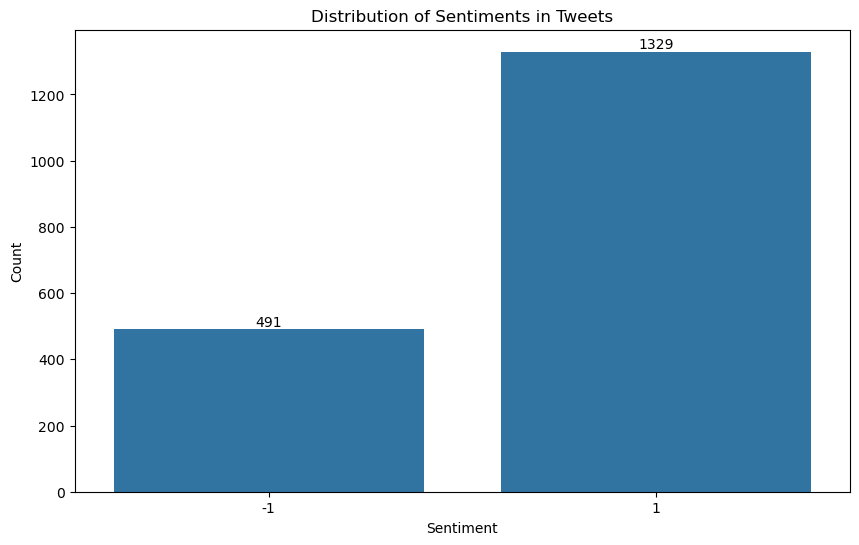

In [64]:
# Create countplot
plt.figure(figsize=(10, 6))
sns.countplot(data=tweet_news, x='sentiment')

plt.title('Distribution of Sentiments in Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Count')

for i in plt.gca().containers:
    plt.gca().bar_label(i)

# Show the plot
plt.show()

In [65]:
tweet_news['sentiment'].value_counts()

sentiment
 1    1329
-1     491
Name: count, dtype: int64

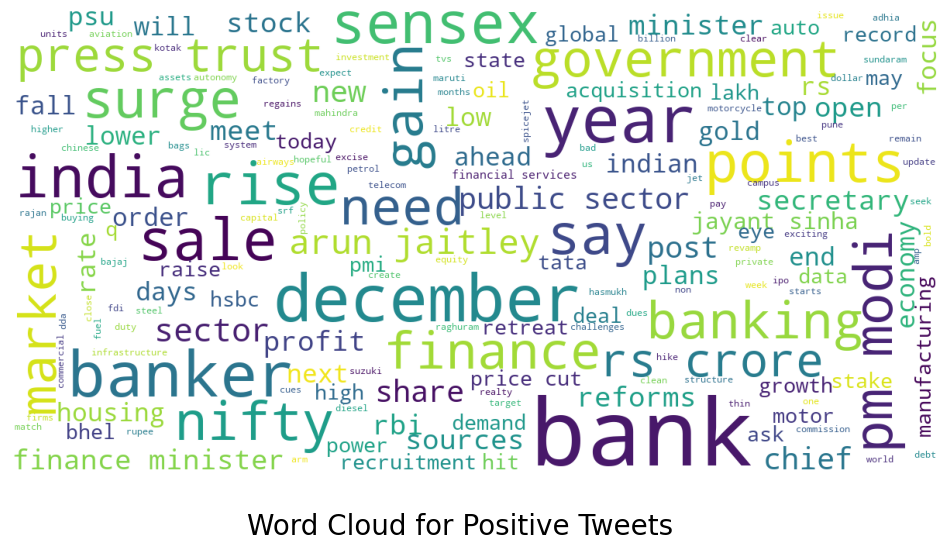

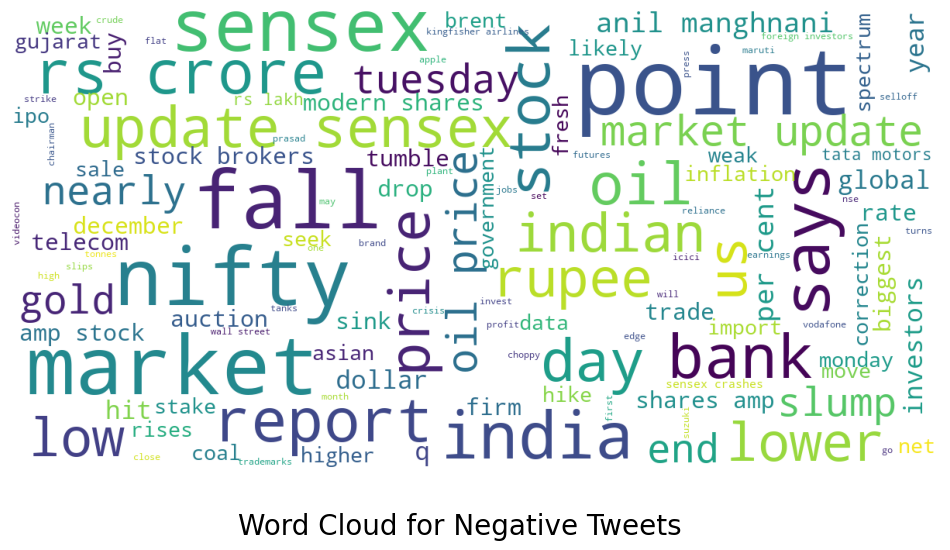

In [66]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
stopwords = set(STOPWORDS)

def show_wordcloud(data, title = None):
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=200000,
        max_font_size=40, 
        scale=3,
        random_state=1).generate(str(data))

    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    if title: 
        fig.suptitle(title, fontsize=20)
        fig.subplots_adjust(top=2.3)

    plt.imshow(wordcloud)
    plt.show()


show_wordcloud(tweet_news[tweet_news['sentiment'] == 1].values, title="Word Cloud for Positive Tweets")

show_wordcloud(tweet_news[tweet_news['sentiment'] == -1].values, title="Word Cloud for Negative Tweets")

Probability Distribution of Sentiment Scores by VADER. Plot the probability distribution of the tweet_news column score. What can you say about the confidence of VADER in detecting either positive or negative sentiments?

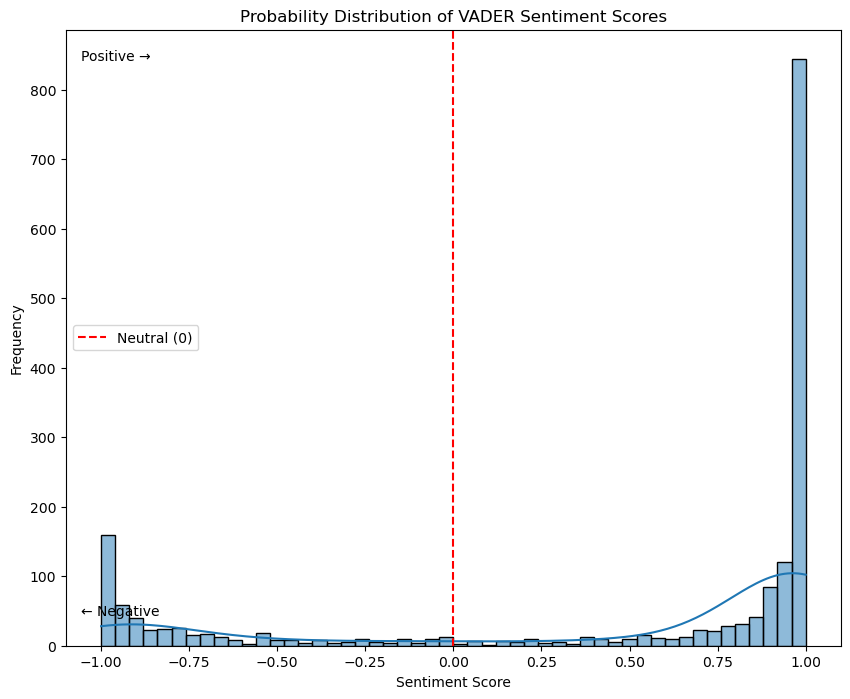

count    1820.000000
mean        0.447384
std         0.772726
min        -0.999500
25%        -0.226300
50%         0.942800
75%         0.994050
max         0.999900
Name: score, dtype: float64


In [73]:
# plot the probability distribution here, you can use sns.histplot
# Create the distribution plot
plt.figure(figsize=(10, 8))

# Plot the distribution
sns.histplot(data=tweet_news, x='score', bins=50, kde=True)

# Add vertical lines for neutral sentiment
plt.axvline(x=0, color='r', linestyle='--', label='Neutral (0)')

# Customize the plot
plt.title('Probability Distribution of VADER Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.legend()

# Add text annotations for interpretation
plt.text(0.02, 0.95, 'Positive →', transform=plt.gca().transAxes)
plt.text(0.02, 0.05, '← Negative', transform=plt.gca().transAxes)

plt.show()

print(tweet_news['score'].describe())

### Part 2: Long_short Term Memory LSTM  with news polarity

## 1. Prepare the data

Download the index price data `nifty_5yrs.csv` in the dataframe `nifty`

In [88]:
nifty = pd.read_csv('nifty_5yrs.csv')
nifty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1233 non-null   int64  
 1   date        1233 non-null   object 
 2   price       1233 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 29.0+ KB


Based on a concise summary of nifty, we change the data column in proper format. 

In [89]:
nifty['date'] = pd.to_datetime(nifty.date)
nifty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  1233 non-null   int64         
 1   date        1233 non-null   datetime64[ns]
 2   price       1233 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 29.0 KB


Now, we have in dtypes: datetime64

In [90]:
nifty.head()

,Unnamed: 0,date,price
0,0,2015-01-01,8284.00
1,1,2015-01-02,8395.45
2,2,2015-01-05,8378.40
3,3,2015-01-06,8127.35
4,4,2015-01-07,8102.10


In [91]:
tweet_news.head()

,tweet_news_combined,score,sentiment
0,consolidation of psu banks to be key theme at ...,0.9805,1
1,market update nifty regains mark rises with ba...,0.9981,1
4,ashok leyland sales jump in december max indi...,0.9935,1
5,sensex heading for biggest day fall since rupe...,-0.9982,-1
6,sensex correction nearly over says andrew holl...,-0.9930,-1


In [92]:
tweet_news = tweet_news_original.copy()

In [93]:
tweet_news.reset_index(inplace = True)
tweet_news.set_index('date', inplace = True, drop = False)

In [94]:
tweet_news.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1820 entries, 2015-01-01 to 2019-12-31
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1820 non-null   int64  
 1   date                 1820 non-null   object 
 2   tweet_news_combined  1820 non-null   object 
 3   score                1820 non-null   float64
 4   sentiment            1820 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 85.3+ KB


In [95]:
nifty.shape

(1233, 3)

In [96]:
tweet_news.shape

(1820, 5)

In [97]:
from joblib import Parallel, delayed

def drop_rows_by_date(df, dates_to_drop, date_column='date'):
    for date in dates_to_drop:
        df.drop(df[df[date_column] == date].index, inplace=True)


s = set([str(i).split('T')[0] for i in nifty['date'].values])
n = set(list(tweet_news['date'].values))

common_dates_1 = list(n.symmetric_difference(s))

# Filter and drop rows not in nifty dates
nifty_dates = {str(i).split('T')[0] for i in nifty['date'].values}
tweet_news['date_str'] = tweet_news['date'].apply(lambda x: str(x).split('T')[0])

rows_to_drop = tweet_news[~tweet_news['date_str'].isin(nifty_dates)].index
tweet_news.drop(rows_to_drop, inplace=True)

# Drop rows based on common_dates_1 using parallel processing
Parallel(n_jobs=-1)(
    delayed(drop_rows_by_date)(df, common_dates_1) for df in [tweet_news, nifty]
)

# Remove the temporary 'date_str' column
tweet_news.drop(columns=['date_str'], inplace=True)

# Display updated DataFrames
print(tweet_news)
print(nifty)


            index        date  \
date                            
2015-01-01      0  2015-01-01   
2015-01-02      1  2015-01-02   
2015-01-05      4  2015-01-05   
2015-01-06      5  2015-01-06   
2015-01-07      6  2015-01-07   
...           ...         ...   
2019-12-24   1812  2019-12-24   
2019-12-26   1814  2019-12-26   
2019-12-27   1815  2019-12-27   
2019-12-30   1818  2019-12-30   
2019-12-31   1819  2019-12-31   

                                          tweet_news_combined   score  \
date                                                                    
2015-01-01  consolidation of psu banks to be key theme at ...  0.9805   
2015-01-02  market update nifty regains mark rises with ba...  0.9981   
2015-01-05  ashok leyland sales jump in december  max indi...  0.9935   
2015-01-06  sensex heading for biggest day fall since rupe... -0.9982   
2015-01-07  sensex correction nearly over says andrew holl... -0.9930   
...                                                       .

Explain, what was done in the cell above.

In [98]:
tweet_news.shape


(1233, 5)

In [99]:
nifty.shape

(1233, 3)

In [100]:
tweet_news['date'] = tweet_news['date'].astype(str)
nifty['date'] = nifty['date'].astype(str)

In [102]:
tweet_news = tweet_news.drop('date', axis=1)

In [103]:
data1 = pd.merge(tweet_news, nifty, on='date')

In [104]:
data1.head()

,date,index,tweet_news_combined,score,sentiment,Unnamed: 0,price
0,2015-01-01,0,consolidation of psu banks to be key theme at ...,0.9805,1,0,8284.00
1,2015-01-02,1,market update nifty regains mark rises with ba...,0.9981,1,1,8395.45
2,2015-01-05,4,ashok leyland sales jump in december max indi...,0.9935,1,2,8378.40
3,2015-01-06,5,sensex heading for biggest day fall since rupe...,-0.9982,-1,3,8127.35
4,2015-01-07,6,sensex correction nearly over says andrew holl...,-0.9930,-1,4,8102.10


In [105]:
data = data1[['date', 'score', 'price']]

## 2. Train and test sets

We split the 5 years stock data in Train-CV-Test in the ratio 64:16:20
First split data into train_data and test_data in the ratio 80:20
Then, split train_data to X_train and X_cv in the ratio 80:20

In [106]:
data.head()

,date,score,price
0,2015-01-01,0.9805,8284.00
1,2015-01-02,0.9981,8395.45
2,2015-01-05,0.9935,8378.40
3,2015-01-06,-0.9982,8127.35
4,2015-01-07,-0.9930,8102.10


In [107]:
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)
X_train, X_cv = train_test_split(train_data, test_size=0.2, shuffle=False)

In [108]:
X_train = X_train.set_index('date', drop= False)
X_cv = X_cv.set_index('date', drop= False)
test_data = test_data.set_index('date', drop= False)

In [109]:
len(X_train), len(X_cv), len(test_data)

(788, 198, 247)

In [110]:
(36931, 9233, 11542)

(36931, 9233, 11542)

In [111]:
def create_dataset(dataset, scoreset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		b = scoreset[i+look_back-1]
		dataX.append(np.append(a,b))
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)

In [112]:
# Feature Scaling
sc = MinMaxScaler()
training_set_scaled = sc.fit_transform(X_train['price'].values.reshape(-1, 1))
cv_set_scaled = sc.transform(X_cv['price'].values.reshape(-1, 1))
test_set_scaled = sc.transform(test_data['price'].values.reshape(-1, 1))

sc1 = MinMaxScaler()
training_score_scaled = sc1.fit_transform(X_train['score'].values.reshape(-1, 1))
cv_score_scaled = sc1.transform(X_cv['score'].values.reshape(-1, 1))
test_score_scaled = sc1.transform(test_data['score'].values.reshape(-1, 1))

In [113]:
#Creating Dataset with window size = 60 + News Sentiment of Last Day

trainX, trainY = create_dataset(training_set_scaled, training_score_scaled, 60)
cvX, cvY = create_dataset(cv_set_scaled, cv_score_scaled, 60)
testX, testY = create_dataset(test_set_scaled, test_score_scaled, 60)

In [114]:
trainX.shape, cvX.shape, testX.shape

((727, 61), (137, 61), (186, 61))

Explain lightly what was done in the previous cells. What information are we using to predict the stock price for next day?

In [115]:
#Reshaping all data.

trainX, trainY = np.array(trainX), np.array(trainY)
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

cvX, cvY = np.array(cvX), np.array(cvY)
cvX = np.reshape(cvX, (cvX.shape[0], cvX.shape[1], 1))

testX, testY = np.array(testX), np.array(testY)
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

## 3. LSTM

In [118]:
!pip install torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter


# Set seeds for reproducibility
torch.manual_seed(26)
np.random.seed(26)


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   - -------------------------------------- 5.5/204.1 MB 27.9 MB/s eta 0:00:08
   -- ------------------------------------- 11.0/204.1 MB 26.5 MB/s eta 0:00:08
   --- ------------------------------------ 16.8/204.1 MB 26.4 MB/s eta 0:00:08
   ---- ----------------------------------- 22.0/204.1 MB 25.8 MB/s eta 0:00:08
   ----- ---------------------------------- 27.0/204.1 MB 25.9 MB/s eta 0:00:07
   ------ --------------------------------- 31.2/204.1 MB 24.7 MB/s eta 0:00:07
   ------- -------------------------------- 36.7/204.1 MB 24.8 MB/s eta 0:00:07
   -------- ------------------------------- 41.7/204.1 MB 24.8 MB/s eta 0:00:07
   --------- ------------------------------ 47.2/204.1 MB 25.0 MB/s eta 0:00:07
   ---------- ----------------------------- 52.7/204.1 MB 25.0 MB/s eta 0:00:07
   ----------- ---------------------------- 58.2/204

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Convert data to PyTorch tensors:

In [119]:

trainX_t = torch.FloatTensor(trainX).squeeze()  # Remove singleton dimensions if they exist
if trainX_t.ndim == 2:
    trainX_t = trainX_t.unsqueeze(-1)  # Add feature dimension if needed
trainY_t = torch.FloatTensor(trainY)

cvX_t = torch.FloatTensor(cvX).squeeze()
if cvX_t.ndim == 2:
    cvX_t = cvX_t.unsqueeze(-1)  # Add feature dimension if needed
cvY_t = torch.FloatTensor(cvY)

Create dataloaders:

In [120]:
# Create DataLoaders
train_dataset = TensorDataset(trainX_t, trainY_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
cv_dataset = TensorDataset(cvX_t, cvY_t)
cv_loader = DataLoader(cv_dataset, batch_size=64)

Configuration Class

In [121]:

class Config:
    seed = 26
    batch_size = 64
    hidden_size = 128
    learning_rate = 0.01
    epochs = 30
    patience = 5
    grad_clip = 1.0

Setup

In [122]:
def setup_environment(config):
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return device

Model Class

In [123]:
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)

    def forward(self, x):
        if x.ndim == 4: x = x.squeeze(1)
        if x.ndim == 2: x = x.unsqueeze(-1)
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:, -1, :])

Training Orchestration

In [124]:
def train_model(config, model, train_loader, cv_loader, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(config.epochs):
        # Training phase
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = torch.sqrt(nn.MSELoss()(outputs, batch_y))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in cv_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X).squeeze()
                val_loss += torch.sqrt(nn.MSELoss()(outputs, batch_y)).item()

        # Early stopping logic
        avg_val_loss = val_loss / len(cv_loader)
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == config.patience:
                print(f"Early stopping at epoch {epoch}")
                break

        scheduler.step(avg_val_loss)

Main Execution

In [125]:
if __name__ == "__main__":
    config = Config()
    device = setup_environment(config)
    
    # Data preparation (assumes trainX/trainY exist)
    trainX_t = torch.FloatTensor(trainX).squeeze()
    if trainX_t.ndim == 2: trainX_t = trainX_t.unsqueeze(-1)
    train_dataset = TensorDataset(trainX_t, torch.FloatTensor(trainY))
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    
    # Initialize and train model
    model = EnhancedLSTM().to(device)
    train_model(config, model, train_loader, cv_loader, device)

Early stopping at epoch 14


You can try the following tensorboard code for visualization, unfortunately it does not work with the newer versions of Python.

In [ ]:
#%load_ext tensorboard


In [ ]:
# %tensorboard --logdir logs/pytorch


In [126]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Assuming you have your test data prepared similarly to your training data
testX_t = torch.FloatTensor(testX).squeeze()
if testX_t.ndim == 2:
    testX_t = testX_t.unsqueeze(-1)
testY_t = torch.FloatTensor(testY)


In [127]:

# Make predictions
model.eval()
with torch.no_grad():
    predictions = model(testX_t).squeeze().numpy()
actual = testY_t.numpy()


Plot a scatter Plot of Actual vs Predicted

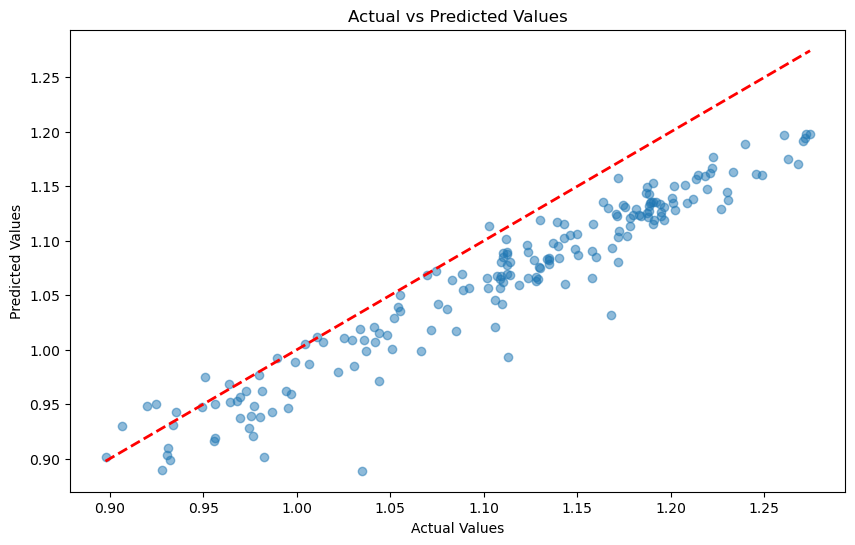

In [128]:

plt.figure(figsize=(10, 6))
plt.scatter(actual, predictions, alpha=0.5)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values') 
plt.title('Actual vs Predicted Values')
plt.show()



Residual Plot

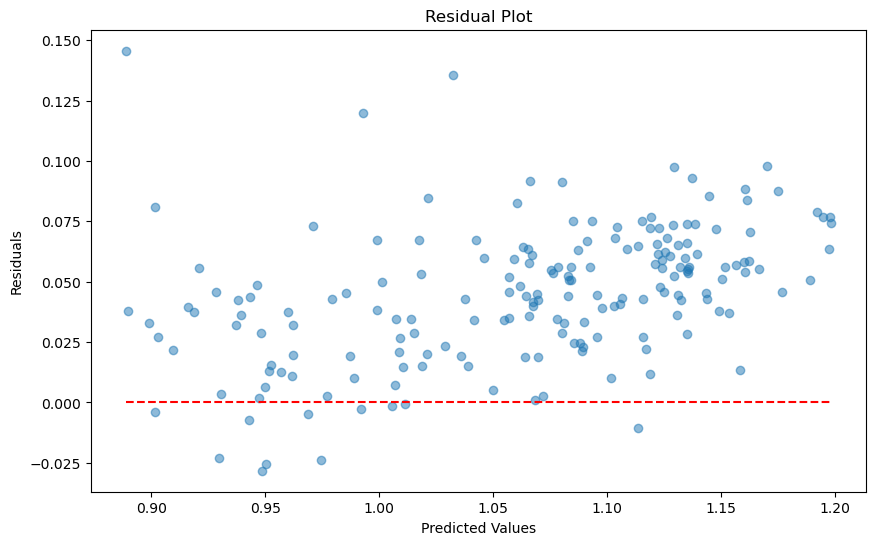

In [129]:
residuals = actual - predictions
plt.figure(figsize=(10, 6))
plt.scatter(predictions, residuals, alpha=0.5)
plt.hlines(y=0, xmin=predictions.min(), xmax=predictions.max(), colors='r', linestyles='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


Evaluation Metrics

In [131]:

mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)

print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'R-squared Score: {r2:.4f}')


Mean Squared Error: 0.0028
Root Mean Squared Error: 0.0531
Mean Absolute Error: 0.0464
R-squared Score: 0.6752


What do the above evaluation metrics mean. How well does the model perform? How can you adjust the model to perform better?

Please plot the residuals.

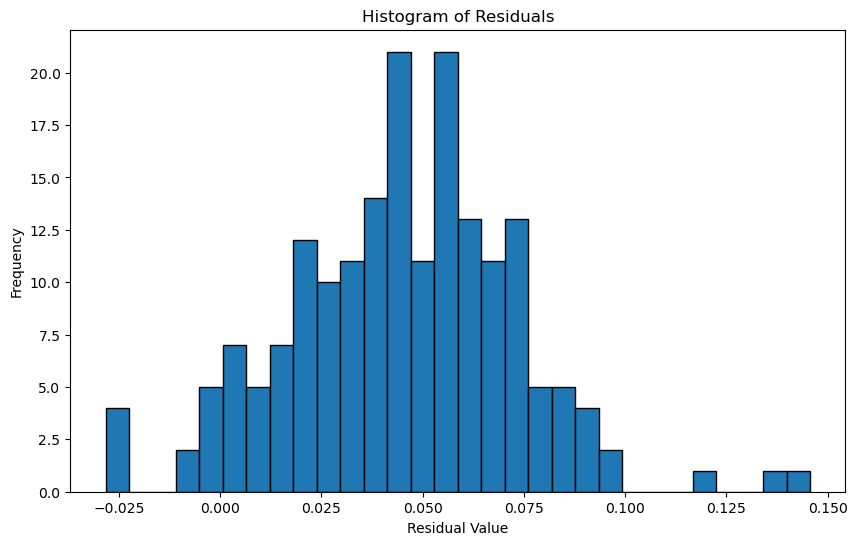

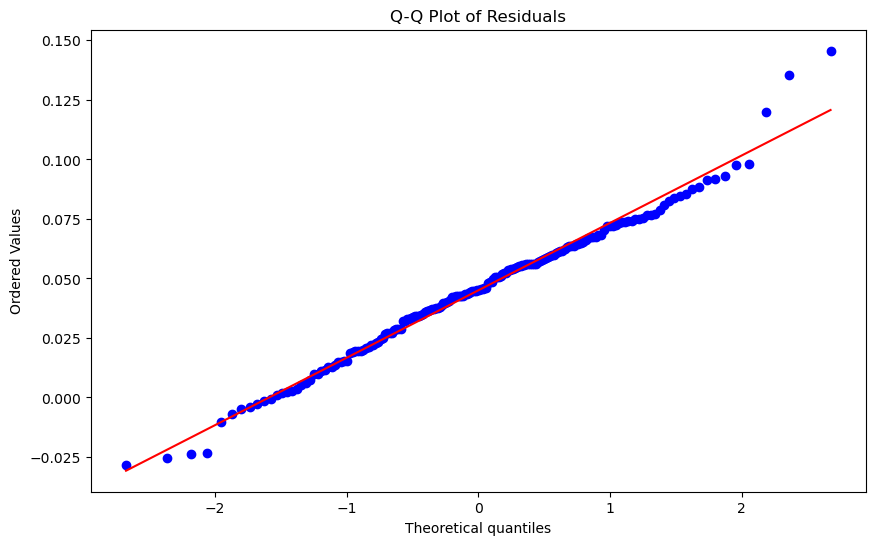

In [133]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

from scipy import stats
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()



Here plot the times series of the actual data, and the predictions. How well did you succeed?

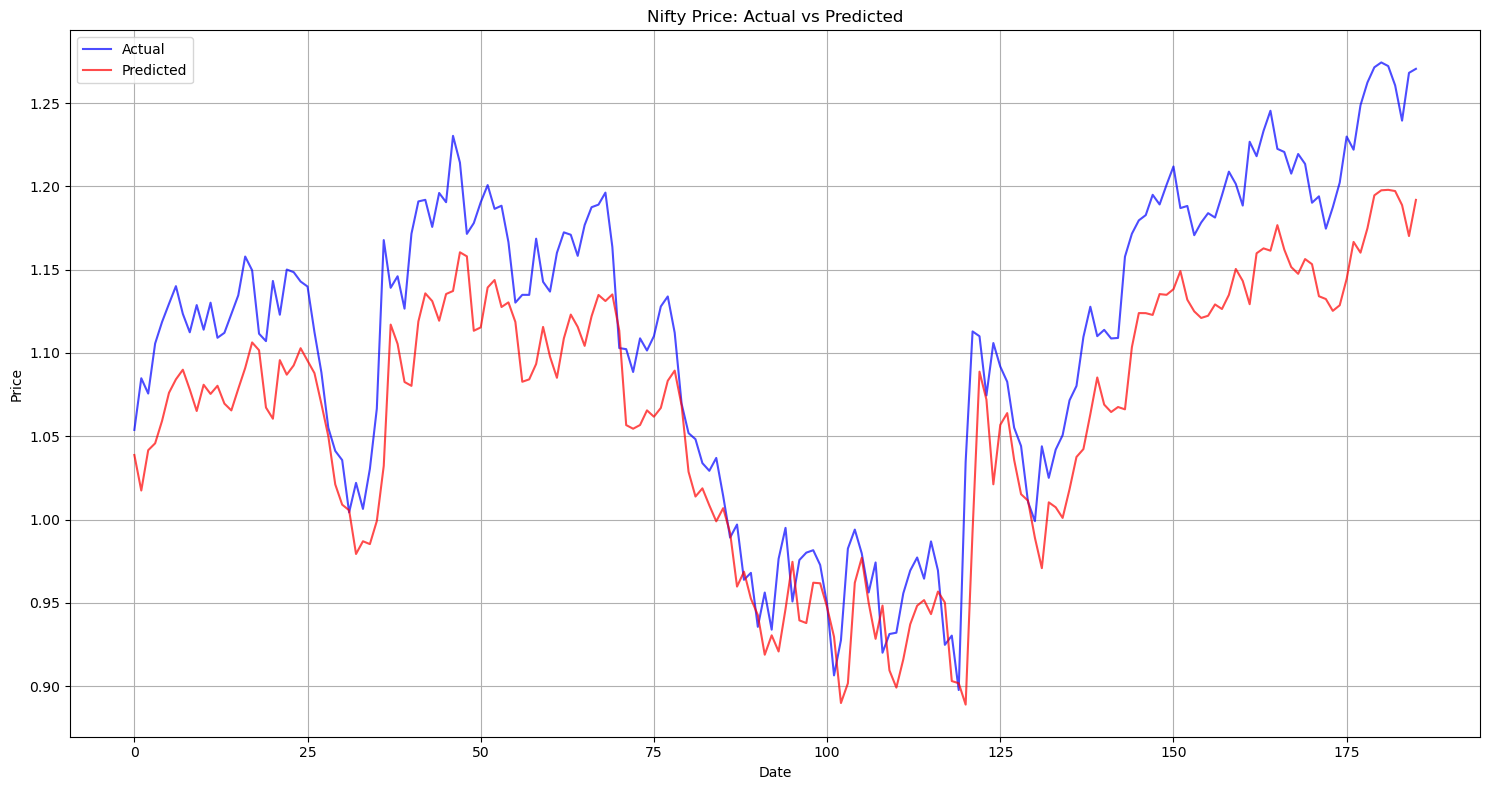

In [152]:
plt.figure(figsize=(15, 8));
plt.plot(actual, label='Actual', color='blue', alpha=0.7)
plt.plot(predictions, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Date'); plt.ylabel('Price'); plt.title('Nifty Price: Actual vs Predicted')
plt.legend();
plt.grid(True);
plt.tight_layout(); 
plt.show()


## Further: Scraping data from the web


In [ ]:
#Data is scraped from this url: https://in.investing.com/indices/s-p-cnx-nifty-historical-data?end_date=1577817000&st_date=946665000

url = 'https://in.investing.com/indices/s-p-cnx-nifty-historical-data?end_date=1577817000&st_date=946665000'
req = Request(url , headers={'User-Agent': 'Mozilla/5.0'})
webpage = urlopen(req).read()
page_soup = soup(webpage, "html.parser")
date_raw = page_soup.find("div", {'class':'common-table-scroller js-table-scroller'}).find_all("td", {"class":"col-rowDate "})
date = [x.text.split("\n")[1] for x in date_raw]
price_raw = []
for i in range(4972):
    price_raw.append(page_soup.find("div", {'class':'common-table-scroller js-table-scroller'}).find_all("td")[i*7:(i+1)*7][1].text)
price = [float(x.split("\n")[1].replace(",", "")) for x in price_raw]
nifty = pd.DataFrame(list(zip(date, price)), columns=['date', 'price'])

In [ ]:
pip install faust-cchardet

In [ ]:
import twint

In [ ]:
#configuration

config = twint.Config()
config.Username = "NDTVProfit"
config.Lang = "en"
config.Since = "2015-01-01"
config.Until = "2020-01-01"
#config.Store_csv = True
#config.Output = "NDTVProfit.csv"
#running search
twint.run.Search(config)